# Sprint 10
## Nivel 1
### Ejercicio 1

- Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

- Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

- Mostra les primeres 10 files.

- Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Importación del DataFrame
# header=3 para saltarnos las 3 primeras filas del excel

ruta_archivo = "sprint10.xlsx"

df_empleados = pd.read_excel(ruta_archivo, header=3)

# limpiamos la columna unnamed
df_empleados = df_empleados.drop(['Unnamed: 0'],axis=1)

df_empleados = df_empleados.sort_values(by=["País d'origen", "Ciutat"], ascending=True, ignore_index=True)

df_empleados.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.00,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.00,NaN,Grup B
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.00,Grup B
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.00,NaN,Grup B
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.00,NaN,Grup D
5,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.00,NaN,Grup A
6,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.00,Grup A
7,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.00,Grup C
8,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.00,NaN,Grup C
9,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.00,Grup B


In [3]:
# comprobación de DNIs únicos
total_filas = len(df_empleados)
dnis_unicos = df_empleados['DNI'].nunique()
es_unico = total_filas == dnis_unicos
#es_unico

if es_unico:
    print("Todos los DNI son únicos. No hay duplicados.")
else:
    print("Se han detectado DNIs duplicados en el conjunto de datos.")

Todos los DNI son únicos. No hay duplicados.


### Ejercicio 2
- Crea una columna que sigui el nom complet.
- Crea una columna si la persona és nascuda a Espanya o no.
- Posa el DNI com a índex del DataFrame (noms de files).
- Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
- Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
- Mostra tots els canvis que has realitzat en una sola taula.

In [4]:
# Crear nueva columna que sea el nombre completo
df_empleados['Nom Complet'] = (df_empleados['Nom'] + " " + df_empleados['Cognoms'])

# Crear una columna si la persona es nacida en España o no.
df_empleados['Nascut a Espanya'] = np.where(df_empleados["País d'origen"] == "Espanya", "Sí", "No")

# Renombrar columnas
nuevos_nombres = {
    "Dia de Naixement": "Dia",
    "Mes de Naixement": "Mes",
    "Any de Naixement": "Any",
}

df_empleados = df_empleados.rename(columns=nuevos_nombres)

# Pasar el DNI al índice
df_empleados = df_empleados.set_index("DNI")

# Reemplazo de valores en columna género
mapeo_genero = {
    "H": "Home",
    "D": "Dona",
    "A": "Altres",
    "NC": np.nan
}

df_empleados['Gènere'] = df_empleados['Gènere'].replace(mapeo_genero)

df_empleados

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.00,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.00,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.00,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.00,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.00,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.00,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.00,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.00,Grup A,Olivia Brown Brown,No


### Ejercicio 3
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [5]:
def determinar_hijos(fila):
    tiene_hijos = fila['Fills']
    no_tiene_hijos = fila['No Fills']

    # evaluamos la columna 'Fills'
    if not pd.isna(tiene_hijos) and (tiene_hijos == 1):
        return "Sí"
    
    # evaluamos la columna 'No Fills'
    elif not pd.isna(no_tiene_hijos) and (no_tiene_hijos == 1):
        return "No"
    
    # caso si ambas celdas son NaN o están vacías
    else:
        return "No"

# aplicamos la función en la nueva columna
df_empleados['Fills_Final'] = df_empleados.apply(determinar_hijos, axis=1)

# borramos columnas originales
df_empleados = df_empleados.drop(columns=['Fills', 'No Fills'])

# renombramos la columna como nos solicitan
df_empleados = df_empleados.rename({'Fills_Final': 'Fills'}, axis=1)

#visualizamos una muestra del dataframe
df_empleados.head(10)


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Grup Professional,Nom Complet,Nascut a Espanya,Fills
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,Grup A,Mia Schneider Fischer,No,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Grup B,Laura Schneider Fischer,No,Sí
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,Grup B,Lea Schneider Schneider,No,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Grup B,Mia Fischer,No,Sí
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Grup D,Jonas Schneider,No,Sí
14773153R,Lea,Fischer,Alemanya,Berlín,9,9,1986,Dona,1.370 €,Grup A,Lea Fischer,No,Sí
23266650S,Lea,Müller,Alemanya,Hamburg,14,4,2003,Dona,1.314 €,Grup A,Lea Müller,No,No
83274277X,Anna,Müller,Alemanya,Hamburg,1,1,1987,Dona,2.464 €,Grup C,Anna Müller,No,No
60161784X,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,Grup C,Laura Schmidt Müller,No,Sí


### Ejercicio 4
- Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
- Ordena la taula en funció del sou mig.

In [6]:
# limpieza de la columna 'Salari mensual'
df_empleados['Salari mensual'] = df_empleados['Salari mensual'].astype(str)

# eliminamos el símbolo € y los espacios ne blanco
df_empleados['Salari mensual'] = df_empleados['Salari mensual'].str.replace("€", "", regex=False)

df_empleados['Salari mensual'] = df_empleados['Salari mensual'].str.strip()

# quitamos los puntos de miles
df_empleados['Salari mensual'] = df_empleados['Salari mensual'].str.replace(".", "", regex=False)

# convertimos la columna final a números decimales (float)
df_empleados['Salari mensual'] = pd.to_numeric(
    df_empleados['Salari mensual'], errors="coerce"
)

# agrupación por género
df_resumen_salario = (
    df_empleados.groupby('Gènere')['Salari mensual']
    .agg(
        Salari_Mitjà="mean", Salari_Medià="median", Salari_Mínim="min", Salari_Màxim="max"
    )
    .reset_index()
)

# ordenamos
df_resumen_salario = df_resumen_salario.sort_values(by='Salari_Mitjà', ascending=False)

df_resumen_salario

,Gènere,Salari_Mitjà,Salari_Medià,Salari_Mínim,Salari_Màxim
2,Home,1643.25,1531.00,737,3356
0,Altres,1626.59,1545.00,703,3175
1,Dona,1469.44,1361.50,665,3021


### Ejercicio 5
- Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
- Afegeix-hi les mitjanes als marges de la taula.
- (EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

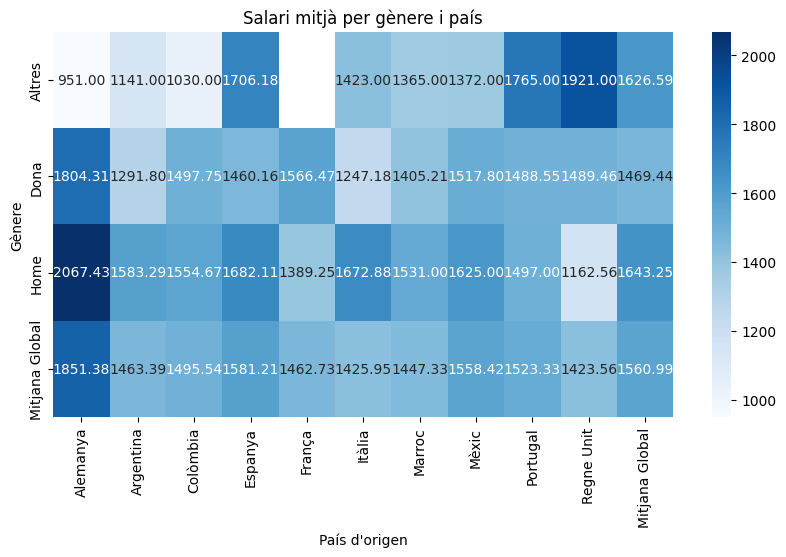

In [7]:
# creación de la tabla
# usamos pd.crosstab para cruzar género (filas) y país (columnas)
# 'values' define sobre qué columna operamos y 'aggfunc' el cálculo que queremos
# 'margins=True' añade las medias a las filas y columnas

tabla_pivot = pd.crosstab(
    index=df_empleados['Gènere'],
    columns=df_empleados['País d\'origen'],
    values=df_empleados['Salari mensual'],
    aggfunc="mean",
    margins=True,
    margins_name="Mitjana Global"
)

# aplicación de formato condicional con seaborn
# creamos un lienzo para el gráfico
plt.figure(figsize=(10,5))

# generamos un mapa de calor
# 'annot=True' escribe los números dentro de las celdas
# 'fmt=".2f"' asegura que los números salgan con dos decimales
# 'cmap="Blues"' aplica una escala, mayor salario = más intenso el color

sns.heatmap(tabla_pivot, annot=True, fmt=".2f", cmap="Blues", cbar=True)

#titulos
plt.title("Salari mitjà per gènere i país")
plt.ylabel("Gènere")
plt.xlabel("País d'origen")

plt.show()

### Ejercicio 6
- Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
- Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [8]:
# creacion de la columna datetime
df_empleados['Data de Naixement'] = pd.to_datetime(
    df_empleados[["Dia", "Mes", "Any"]].rename(
        columns={"Dia": "day", "Mes": "month", "Any": "year"}
    )
)

# función para calcular la edad actual
def calcular_edad(fecha_nacimiento):
    
    # si la fecha es nula, devolvemos valor nulo para no romper el código
    if pd.isna(fecha_nacimiento):
        return None
    
    # obtenemos la fecha exacta del dia
    hoy = datetime.today()

    # cálculo diferencia de años
    edad = hoy.year - fecha_nacimiento.year

    ha_cumplido = (hoy.month, hoy.day) >= (
        fecha_nacimiento.month,
        fecha_nacimiento.day,
    )

    if not ha_cumplido:
        edad = edad - 1

    return edad

# generar la columna de edad actual .apply

df_empleados['Edad Actual'] = df_empleados['Data de Naixement'].apply(calcular_edad)

df_empleados

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Grup Professional,Nom Complet,Nascut a Espanya,Fills,Data de Naixement,Edad Actual
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,Grup A,Mia Schneider Fischer,No,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Grup B,Laura Schneider Fischer,No,Sí,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,Grup B,Lea Schneider Schneider,No,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Grup B,Mia Fischer,No,Sí,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Grup D,Jonas Schneider,No,Sí,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,Grup B,Emily Taylor Jones,No,No,1958-03-28,68
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Grup A,George Brown Jones,No,Sí,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,Grup A,Olivia Brown Brown,No,No,1952-08-28,73


## Nivel 2
### Ejercicio 1
- Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
- Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

In [9]:
# creación del dataframe increment
df_increment = pd.DataFrame(
    {
        "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
        "Increment": ["5%", "3,5%", "2%", "8%"],
    }
)

#limpieza del porcentaje (de texto a float)
#eliminamos el %

df_increment['Increment_net'] = df_increment['Increment'].str.replace("%", "", regex=False)

#cambio coma decimal por un punto
df_increment['Increment_net'] = df_increment['Increment_net'].str.replace(",", ".", regex=False)

#convertimos a formato float
df_increment['Increment_multiplicador'] = pd.to_numeric(df_increment['Increment_net'])/100

#fusión de tablas pd.merge

df_empleados = pd.merge(
    df_empleados.reset_index(),
    df_increment,
    left_on="Grup Professional",
    right_on="Grup",
    how="left",
).set_index("DNI")

#actualizacion salario
df_empleados['Salari mensual'] = df_empleados['Salari mensual'] * (1 + df_empleados['Increment_multiplicador'])

df_empleados


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Grup Professional,Nom Complet,Nascut a Espanya,Fills,Data de Naixement,Edad Actual,Grup,Increment,Increment_net,Increment_multiplicador
DNI,,,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,Grup A,Mia Schneider Fischer,No,No,1976-10-22,49,Grup A,5%,5,0.05
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.91,Grup B,Laura Schneider Fischer,No,Sí,1958-02-02,68,Grup B,"3,5%",3.5,0.04
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.45,Grup B,Lea Schneider Schneider,No,No,2005-10-23,20,Grup B,"3,5%",3.5,0.04
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.49,Grup B,Mia Fischer,No,Sí,1950-08-11,75,Grup B,"3,5%",3.5,0.04
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Grup D,Jonas Schneider,No,Sí,1985-11-22,40,Grup D,8%,8,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.15,Grup B,Emily Taylor Jones,No,No,1958-03-28,68,Grup B,"3,5%",3.5,0.04
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,Grup A,George Brown Jones,No,Sí,1979-12-27,46,Grup A,5%,5,0.05
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,Grup A,Olivia Brown Brown,No,No,1952-08-28,73,Grup A,5%,5,0.05


### Ejercicio 2
- Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
- Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...
- Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [11]:
# exportacion con bucle
grupos_unicos = df_empleados['Grup Professional'].unique()

for grup in grupos_unicos:
    df_filtrado = df_empleados[df_empleados['Grup Professional'] == grup]

    nombre_archivo = f"dades{grup.replace(' ', '')}.xlsx"

    # exportamos
    df_filtrado.to_excel(nombre_archivo)
    print(f"Archivo exportado con éxito: {nombre_archivo}")

#creación de dataframe

df_resumen_grupos = (
    df_empleados.groupby('Grup Professional')
    .agg(
        Total_treballadors = ("Nom", "count"),
        Salari_Mitjà = ("Salari mensual", "mean"),
        Edat_Mediana = ("Edad Actual", "median"),
    )
    .reset_index()
)

# exportación dataframe resumen
archivo_resumen = "resum_grup_professional.xlsx"
df_resumen_grupos.to_excel(archivo_resumen, index=False)

print(f"Archivo resumen exportado con éxito: {archivo_resumen}")

df_resumen_grupos

Archivo exportado con éxito: dadesGrupA.xlsx
Archivo exportado con éxito: dadesGrupB.xlsx
Archivo exportado con éxito: dadesGrupD.xlsx
Archivo exportado con éxito: dadesGrupC.xlsx
Archivo resumen exportado con éxito: resum_grup_professional.xlsx


,Grup Professional,Total_treballadors,Salari_Mitjà,Edat_Mediana
0,Grup A,490,1213.32,51.00
1,Grup B,318,1724.55,48.00
2,Grup C,137,2289.19,52.00
3,Grup D,55,3100.82,44.00
